In [2]:
import torch
from src.data.criterion.nonogram import NonogramLoss
import os
import matplotlib.pyplot as plt
os.chdir(os.path.join(os.getcwd(), '..'))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
loss_fn = NonogramLoss().to(device)

In [4]:
def inspect_loss(pred, target):
    pred = pred.to(device)
    target = target.to(device)
    loss = loss_fn(pred, target)
    return loss[0].item()  # Return the loss value as a scalar

def visualise_matrix(matrix):
    inv_matrix = 1 - matrix  # Invert the values: 1 becomes 0, and 0 becomes 1
    plt.imshow(inv_matrix.cpu().numpy(), cmap='gray') #black = 1, white = 0
    plt.colorbar()
    plt.show()


In [5]:
clues = torch.tensor([[
    [[2,1,0], [2,1,0], [4,0,0], [0,0,0], [1,0,0]], 
    [[1,0,0], [3,1,0], [1,1,0], [2,0,0], [1,1,0]]]], dtype=torch.float32).to(device)

prediction = torch.tensor(
    [[1.0014e-05, 1.0000e+00, 9.9994e-01, 9.1891e-04, 9.9995e-01],
    [9.9985e-01, 9.9999e-01, 6.6493e-07, 9.9952e-01, 1.2902e-06],
    [1.2206e-07, 9.9999e-01, 1.0000e+00, 9.9992e-01, 2.6861e-06],
    [1.2406e-05, 5.3901e-06, 2.8755e-06, 2.5100e-05, 1.8330e-05], 
    [4.6413e-06, 8.8982e-01, 7.8406e-07, 1.9021e-07, 7.8025e-01]], dtype=torch.float32).to(device)

prediction1d = prediction.view(-1, 25)

prediction2 = torch.tensor(
    [[1.1203e-02, 9.9997e-01, 9.9914e-01, 3.3869e-04, 9.9997e-01],
    [9.9962e-01, 9.9993e-01, 3.0037e-04, 9.9998e-01, 2.3297e-05],
    [1.7471e-05, 4.8555e-01, 9.9997e-01, 9.2215e-01, 9.9396e-01],
    [3.9934e-05, 3.3531e-01, 4.1223e-05, 3.7045e-03, 2.7134e-04],
    [6.5573e-04, 9.9991e-01, 1.3014e-04, 3.4984e-02, 9.2958e-05]], dtype=torch.float32).to(device)

prediction2_1d = prediction2.view(-1, 25)

true = torch.tensor(
    [[0, 1, 1, 0, 1],
    [1, 1, 0, 1, 0],
    [0, 1, 1, 1, 1],
    [0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0]], dtype=torch.float32).to(device)

true1d = true.view(-1, 25)

In [6]:
print(inspect_loss(prediction1d, clues))
print(inspect_loss(prediction2_1d, clues))
print(inspect_loss(true1d, clues))

0.10075846314430237
0.0596151128411293
0.0


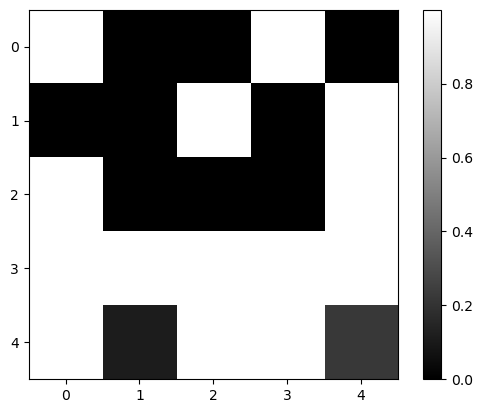

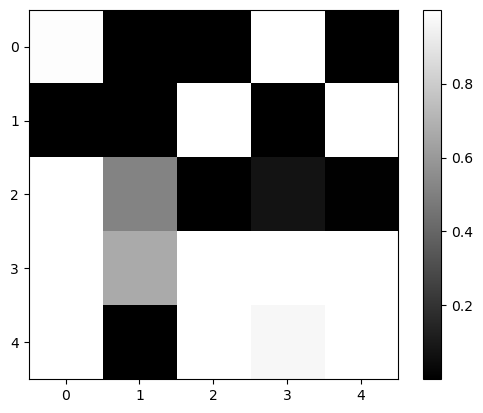

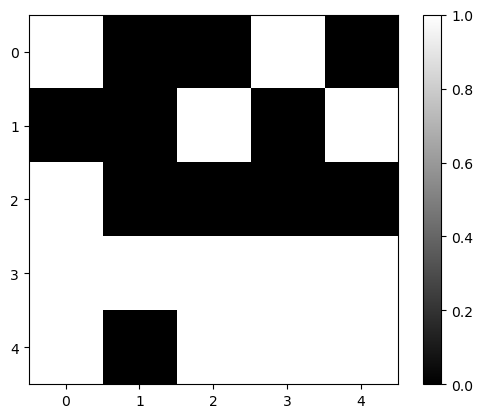

In [7]:
visualise_matrix(prediction)
visualise_matrix(prediction2)
visualise_matrix(true)

In [8]:
def smooth_interpolate(a: torch.Tensor, b: torch.Tensor, t: float | torch.Tensor, method: str = "cosine") -> torch.Tensor:
    a = a.flatten()
    b = b.flatten()
    if a.shape != b.shape or a.dim() != 1:
        raise ValueError("Both tensors must be 1D and have identical shapes.")
        
    # Ensure t is on the same device/dtype and clamp to valid range
    t = torch.clamp(torch.as_tensor(t, dtype=a.dtype, device=a.device), 0.0, 1.0)
    
    if method == "linear":
        w = t
    elif method == "smoothstep":
        w = t * t * (3 - 2 * t)
    elif method == "smootherstep":
        w = t * t * t * (t * (t * 6 - 15) + 10)
    elif method == "cosine":
        w = 0.5 * (1 - torch.cos(torch.pi * t))
    else:
        raise ValueError(f"Unknown method: {method}. Choose from 'linear', 'smoothstep', 'smootherstep', 'cosine'.")
    output = (1 - w) * a + w * b
    return output.unsqueeze(0)  # Add batch dimension back for compatibility

In [9]:
random_guess = torch.rand_like(true)

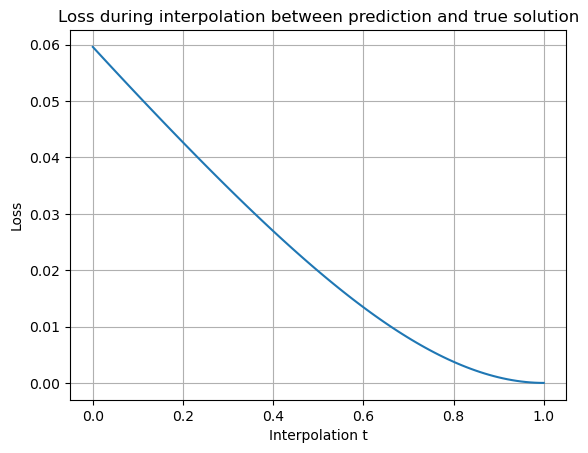

In [10]:
loss_values = [inspect_loss(smooth_interpolate(prediction2_1d, true1d, t=t, method='linear'), clues) for t in torch.linspace(0, 1, steps=100)]
plt.plot(torch.linspace(0, 1, steps=100).cpu(), loss_values)
plt.xlabel('Interpolation t')
plt.ylabel('Loss')
plt.title('Loss during interpolation between prediction and true solution')
plt.grid()
plt.show()

In [65]:
from sklearn.manifold import Isomap
import numpy as np

In [66]:
# X = np.array([[( k >> i) & 1 for i in range(9)] for k in range(512)])
# X_tensor = torch.tensor(X, dtype=torch.float32).to(device)
# correct = torch.tensor([[[2,0],[1,1],[2,0]],[[2,0],[1,1],[2,0]]], dtype=torch.float32).to(device).repeat(512, 1, 1, 1)
X_tensor  = torch.rand(5000, 9).to(device)
correct = torch.tensor([[[2,0],[1,1],[2,0]],[[2,0],[1,1],[2,0]]], dtype=torch.float32).to(device).repeat(5000, 1, 1, 1)

print(X_tensor.shape)
print(correct.shape)

losses = []
for x, y in zip(X_tensor, correct):
    # give each sample a batch size of 1
    x_batch = x.unsqueeze(0)          # (1, 9)
    y_batch = y.unsqueeze(0)          # (1, 2, 3, 2)
    losses.append(inspect_loss(x_batch, y_batch))  # Store the loss value as a scalar

torch.Size([5000, 9])
torch.Size([5000, 2, 3, 2])


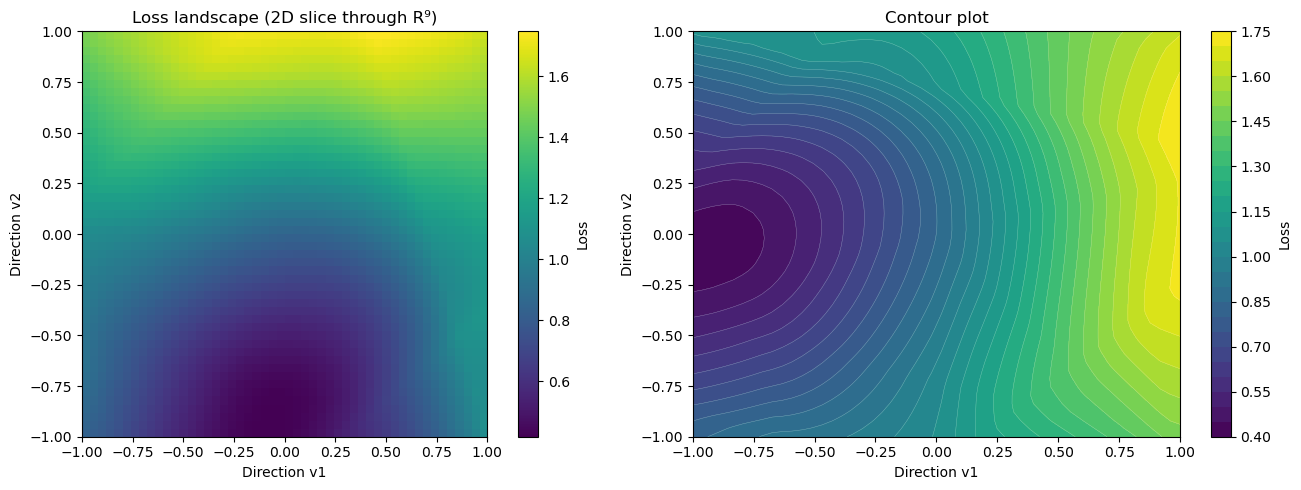

In [70]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# --- 1. Pick two orthonormal directions in R^9 ---
# Option A: random (reveals general landscape shape)
rng = np.random.default_rng()
v1 = rng.standard_normal(9)
v2 = rng.standard_normal(9)

# Orthonormalise via Gram-Schmidt
v1 = v1 / np.linalg.norm(v1)
v2 = v2 - np.dot(v2, v1) * v1
v2 = v2 / np.linalg.norm(v2)

# Option B: use directions between specific input pairs (more interpretable)
# e.g. direction from all-zeros to all-ones for v1
# v1 = np.ones(9) / np.sqrt(9)
# v2 = ... some other meaningful direction

# --- 2. Define the 2D grid ---
center = np.full(9, 0.5)          # centre of the [0,1]^9 hypercube
resolution = 50                    # grid points per axis
alpha_range = np.linspace(-1, 1, resolution)
beta_range  = np.linspace(-1, 1, resolution)

# --- 3. Evaluate loss at each grid point ---
loss_grid = np.zeros((resolution, resolution))

for i, a in enumerate(alpha_range):
    for j, b in enumerate(beta_range):
        x = center + a * v1 + b * v2          # point in R^9
        x = np.clip(x, 0, 1)                  # keep in valid range if needed
        x_tensor = torch.tensor(x, dtype=torch.float32).unsqueeze(0).to(device)
        y_batch = correct[0].unsqueeze(0)
        loss_grid[i, j] = inspect_loss(x_tensor, y_batch)

# --- 4. Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
im = axes[0].imshow(
    loss_grid, origin='lower', cmap='viridis',
    extent=[alpha_range[0], alpha_range[-1], beta_range[0], beta_range[-1]]
)
axes[0].set_xlabel('Direction v1')
axes[0].set_ylabel('Direction v2')
axes[0].set_title('Loss landscape (2D slice through R⁹)')
plt.colorbar(im, ax=axes[0], label='Loss')

# Contour overlay
axes[1].contourf(alpha_range, beta_range, loss_grid.T, levels=30, cmap='viridis')
axes[1].contour( alpha_range, beta_range, loss_grid.T, levels=30, colors='white', linewidths=0.3, alpha=0.4)
axes[1].set_xlabel('Direction v1')
axes[1].set_ylabel('Direction v2')
axes[1].set_title('Contour plot')
plt.colorbar(axes[1].collections[0], ax=axes[1], label='Loss')

plt.tight_layout()
plt.show()

In [68]:
import numpy as np
import matplotlib.pyplot as plt
import torch

def plot_loss_landscape(
    inspect_loss_fn,
    correct,
    device,
    v1,
    v2,
    center=None,
    resolution=60,
    alpha_lim=(-1.5, 1.5),
    beta_lim=(-1.5, 1.5),
    clip_inputs=True,
    mark_points=None,
    title='Loss Landscape',
):
    """
    Visualise the loss landscape over a 2D plane in input space.

    Parameters
    ----------
    inspect_loss_fn : callable(x_batch, y_batch) -> float
    correct         : reference targets tensor (512, ...)
    device          : torch device
    v1, v2          : array-like (9,) — two directions spanning the plane.
                      They will be orthonormalised internally via Gram-Schmidt.
    center          : array-like (9,) — origin of the plane.
                      Defaults to the midpoint of v1 and v2 if they look like
                      points, otherwise [0.5]*9.
    resolution      : grid points per axis
    alpha_lim       : (min, max) sweep range along v1
    beta_lim        : (min, max) sweep range along v2
    clip_inputs     : clip generated inputs to [0, 1]
    mark_points     : list of array-like (9,) — points to mark on the plot
    title           : plot title
    """
    v1 = np.array(v1, dtype=float)
    v2 = np.array(v2, dtype=float)

    if center is None:
        center = np.full(v1.shape, 0.5)
    center = np.array(center, dtype=float)

    # Orthonormalise via Gram-Schmidt
    e1 = v1 / np.linalg.norm(v1)
    e2 = v2 - np.dot(v2, e1) * e1
    e2 = e2 / np.linalg.norm(e2)

    alphas = np.linspace(*alpha_lim, resolution)
    betas  = np.linspace(*beta_lim,  resolution)

    # --- Evaluate loss on the grid ---
    loss_grid = np.zeros((resolution, resolution))
    for i, a in enumerate(alphas):
        for j, b in enumerate(betas):
            x = center + a * e1 + b * e2
            if clip_inputs:
                x = np.clip(x, 0, 1)
            x_t = torch.tensor(x, dtype=torch.float32).unsqueeze(0).to(device)
            y_t = correct[0].unsqueeze(0)
            loss_grid[i, j] = inspect_loss_fn(x_t, y_t)

    # Project any marked points onto (alpha, beta) axes for plotting
    def project(p):
        d = np.array(p, dtype=float) - center
        return np.dot(d, e1), np.dot(d, e2)

    # --- Plot ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title)

    for ax, kind in zip(axes, ('imshow', 'contour')):
        if kind == 'imshow':
            im = ax.imshow(
                loss_grid.T, origin='lower', cmap='viridis',
                extent=[*alpha_lim, *beta_lim], aspect='auto',
            )
            plt.colorbar(im, ax=ax, label='Loss')
            ax.set_title('Heatmap')
        else:
            cf = ax.contourf(alphas, betas, loss_grid.T, levels=30, cmap='viridis')
            ax.contour(alphas, betas, loss_grid.T, levels=30,
                       colors='white', linewidths=0.3, alpha=0.5)
            plt.colorbar(cf, ax=ax, label='Loss')
            ax.set_title('Contour')

        if mark_points:
            for k, pt in enumerate(mark_points):
                a, b = project(pt)
                ax.scatter(a, b, color='red', s=80, zorder=5,
                           edgecolors='white', linewidths=0.8)
                ax.annotate(f'p{k+1}', (a, b), textcoords='offset points',
                            xytext=(6, 4), color='white', fontsize=9)

        ax.set_xlabel('Direction e1')
        ax.set_ylabel('Direction e2')

    plt.tight_layout()
    plt.show()
    return loss_grid, alphas, betas

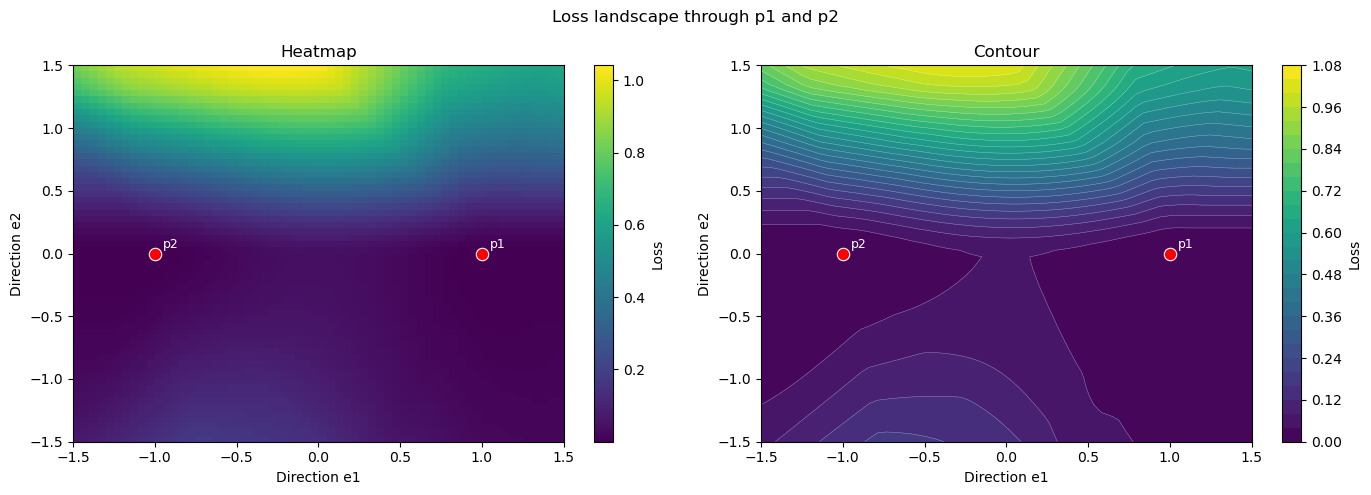

(array([[0.06980999, 0.06396527, 0.05839454, ..., 0.76694381, 0.79445618,
         0.82193017],
        [0.07561621, 0.06939669, 0.06343479, ..., 0.78715676, 0.81475908,
         0.84230208],
        [0.0820713 , 0.07550636, 0.06918322, ..., 0.80750066, 0.83516037,
         0.86274064],
        ...,
        [0.01864718, 0.01737556, 0.01617649, ..., 0.5792644 , 0.59176785,
         0.60429329],
        [0.0183594 , 0.01718579, 0.01607992, ..., 0.58257288, 0.59514624,
         0.60773528],
        [0.01832706, 0.01724512, 0.01622681, ..., 0.58590281, 0.59854233,
         0.61119223]], shape=(60, 60)),
 array([-1.5       , -1.44915254, -1.39830508, -1.34745763, -1.29661017,
        -1.24576271, -1.19491525, -1.1440678 , -1.09322034, -1.04237288,
        -0.99152542, -0.94067797, -0.88983051, -0.83898305, -0.78813559,
        -0.73728814, -0.68644068, -0.63559322, -0.58474576, -0.53389831,
        -0.48305085, -0.43220339, -0.38135593, -0.33050847, -0.27966102,
        -0.22881356, -0.1779

In [69]:
p1 = np.array([1, 1, 0, 1, 0, 1, 0, 1, 1], dtype=float)
p2 = np.array([0, 1, 1, 1, 0, 1, 1, 1, 0], dtype=float)

center = (p1 + p2) / 2
d1 = p1 - center                          # direction along the line p1→p2

# Random vector orthogonal to d1
rng = np.random.default_rng()
rand = rng.standard_normal(9)
d2 = rand - np.dot(rand, d1 / np.linalg.norm(d1)) * (d1 / np.linalg.norm(d1))

dist = np.linalg.norm(d1)

plot_loss_landscape(
    inspect_loss_fn=inspect_loss,
    correct=correct,
    device=device,
    v1=d1,
    v2=d2,                                # orthogonal random direction
    center=center,
    resolution=60,
    alpha_lim=(-dist * 1.5, dist * 1.5),
    beta_lim=(-dist * 1.5, dist * 1.5),
    mark_points=[p1, p2],
    title='Loss landscape through p1 and p2',
)